In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
import matplotlib.pyplot as plt
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf # Make sure tensorflow is imported


# Image Preprocessing Function
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = os.listdir(folder)
    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(folder, class_name)
        if not os.path.isdir(class_folder):
            continue
        for filename in os.listdir(class_folder):
            img_path = os.path.join(class_folder, filename)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Warning: Skipping invalid image {img_path}")
                    continue
                img = cv2.resize(img, (224, 224))
                img = img / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error processing image {img_path}: {e}")
                continue
    return np.array(images), np.array(labels), class_names

# Load Dataset
X, y, class_names = load_images_from_folder(dataset_path)

# Split into Training and Validation Sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Transfer Learning Model
# Call MobileNetV2 using tf.keras.applications
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


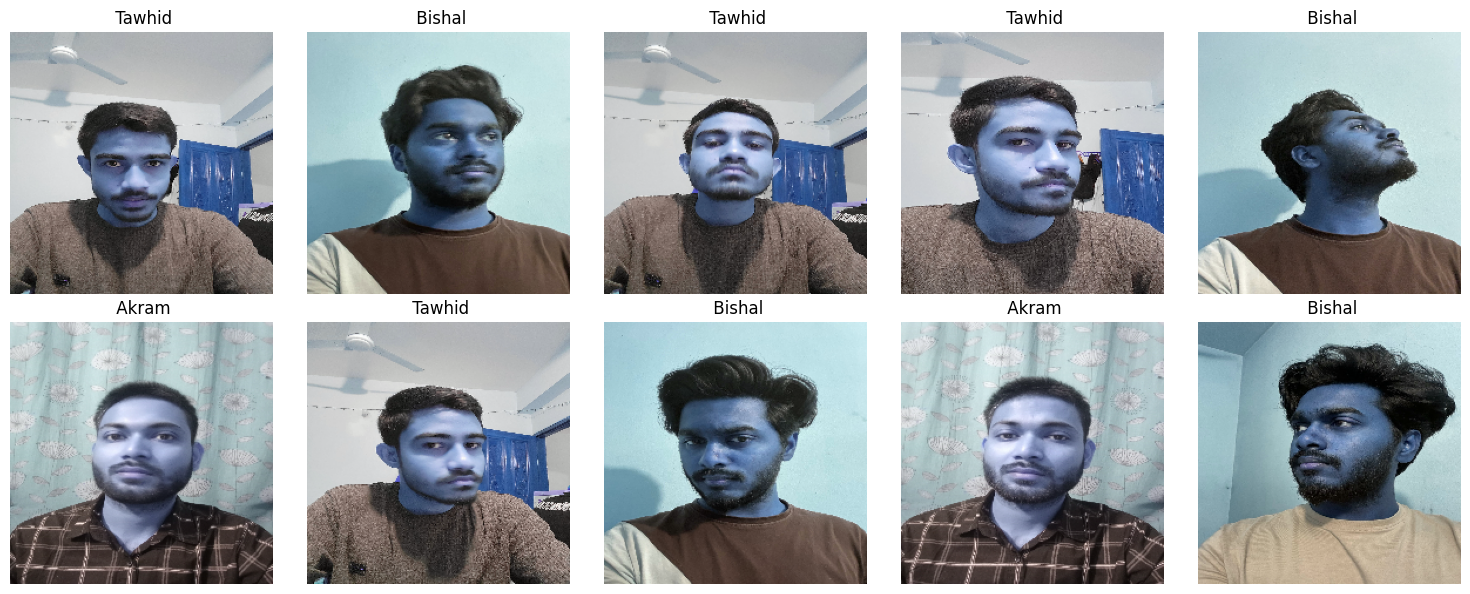

In [ ]:
# Display 10 random images
num_images_to_show = 10
indices = np.random.choice(X.shape[0], num_images_to_show, replace=False)  # Select random indices

# Plot the images using matplotlib
fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # Create a 2x5 grid for the images
axes = axes.flatten()  # Flatten the axes to easily iterate

for i, index in enumerate(indices):
    axes[i].imshow(X[index])  # Display the image
    axes[i].axis('off')  # Turn off axis labels
    axes[i].set_title(f" {class_names[y[index]]}")  # Display the class name

plt.tight_layout()
plt.show()

In [ ]:
# Add Custom Layers
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')  # Output layer for number of classes
])


In [ ]:
# Compile the Model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Data Augmentation
train_datagen = ImageDataGenerator(rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

val_datagen = ImageDataGenerator()

In [ ]:
# Train the Model
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=32),
                    epochs=10,
                    validation_data=val_datagen.flow(X_val, y_val, batch_size=32))


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.3374 - loss: 1.5883 - val_accuracy: 0.4333 - val_loss: 1.0865
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.4194 - loss: 1.1252 - val_accuracy: 0.5000 - val_loss: 0.9323
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.5060 - loss: 1.1276 - val_accuracy: 0.6000 - val_loss: 0.7846
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.6525 - loss: 0.8334 - val_accuracy: 0.8000 - val_loss: 0.6537
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.6290 - loss: 0.7268 - val_accuracy: 0.9000 - val_loss: 0.5490
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - accuracy: 0.7346 - loss: 0.6021 - val_accuracy: 0.9000 - val_loss: 0.4759
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step - accuracy: 0.7368 - loss: 0.5580 - val_accuracy: 0.9000 - val_loss: 0.4180
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - accuracy: 0.8542 - loss: 0.5114 - val_accuracy: 0.9333 - val_loss: 0

In [ ]:
# Evaluate the Model
val_loss, val_accuracy = model.evaluate(val_datagen.flow(X_val, y_val, batch_size=32))
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9667 - loss: 0.2775
Validation Loss: 0.27751636505126953
Validation Accuracy: 0.9666666388511658


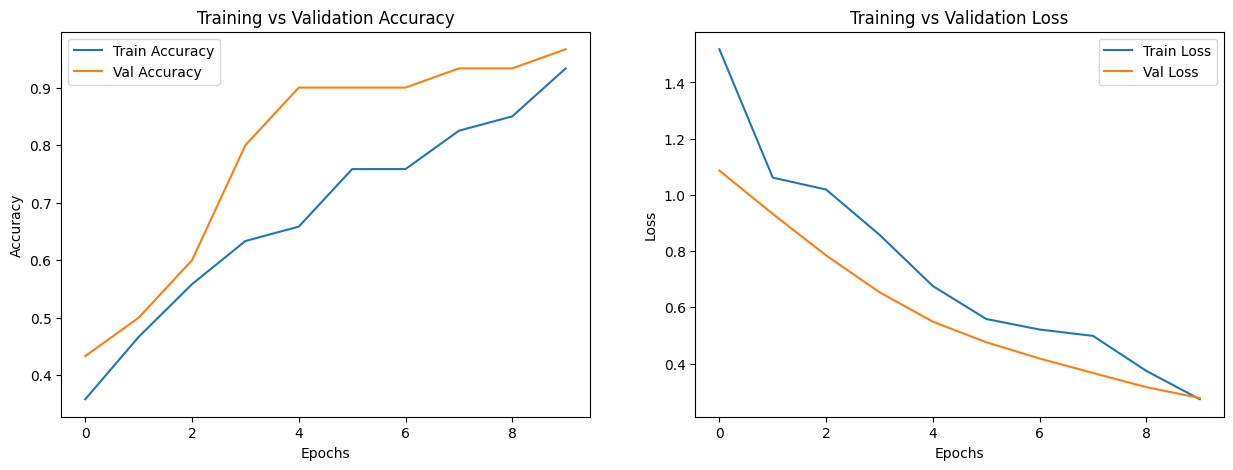

In [ ]:
# Plot Accuracy and Loss
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Save the Model
model.save('/content/drive/MyDrive/face_recognition_model_transfer_learning.keras')


In [ ]:
# Save Pickled Data
with open("/content/drive/MyDrive/X_train.pickle", "wb") as f:
    pickle.dump(X, f)

with open("/content/drive/MyDrive/Y_train.pickle", "wb") as f:
    pickle.dump(y, f)

with open("/content/drive/MyDrive/class_labels.pickle", "wb") as f:
    pickle.dump(class_names, f)

In [ ]:
# Summary of the Model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,751,051 (10.49 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,712 (1.25 MB)